## Notebook 08 — Industrial Sorting Metrics
**Project:** Machine Learning for High Performance Optical Sorting
**Author:** Mohamed Tawfeek
**Description:** Conversion of classification results into industrial metrics: purity, yield, and recovery per class


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
RESULTS_PATH = os.path.join('..', 'results')
FIGURES_PATH = os.path.join('..', 'results', 'figures')
CLASSES = ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']
CLASS_ORDER = sorted(CLASSES)   # sklearn orders classes alphabetically

In [3]:
rf_cm = np.load(os.path.join(RESULTS_PATH, 'rf_confusion_matrix.npy'))
mlp_cm = np.load(os.path.join(RESULTS_PATH, 'mlp_confusion_matrix.npy'))
print("RF confusion matrix loaded, shape:", rf_cm.shape)
print("MLP confusion matrix loaded, shape:", mlp_cm.shape)
print("\nRF confusion matrix:")
print(rf_cm)
print("\nMLP confusion matrix:")
print(mlp_cm)

RF confusion matrix loaded, shape: (6, 6)
MLP confusion matrix loaded, shape: (6, 6)

RF confusion matrix:
[[51  3  2  4  1  0]
 [ 2 55  8  3  7  0]
 [ 3  8 47  0  3  1]
 [ 1  2  6 78  1  1]
 [ 1  4  4  6 57  0]
 [ 0  5  4  0  0 12]]

MLP confusion matrix:
[[53  1  3  1  1  2]
 [ 2 55 10  2  5  1]
 [ 2  7 47  2  3  1]
 [ 1  2  6 77  2  1]
 [ 1  6  1  4 60  0]
 [ 0  1  1  4  1 14]]


In [4]:
# Derives per-class purity (precision), yield (recall), and recovery (Jaccard index) from a confusion matrix, mapping classifier outputs to industrial sorting performance

def compute_industrial_metrics(cm, classes):
    results = []
    
    for i, cls in enumerate(classes):
        TP = cm[i, i]
        FP = np.sum(cm[:, i]) - TP   # everything predicted as class i, minus the correct ones
        FN = np.sum(cm[i, :]) - TP   # everything truly class i, minus the correct ones
        
        purity   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        yield_   = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        recovery = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0.0
        
        results.append({
            'Class':    cls,
            'TP':       int(TP),
            'FP':       int(FP),
            'FN':       int(FN),
            'Purity':   round(purity, 4),
            'Yield':    round(yield_, 4),
            'Recovery': round(recovery, 4)
        })
    
    return pd.DataFrame(results)

rf_metrics  = compute_industrial_metrics(rf_cm,  CLASS_ORDER)
mlp_metrics = compute_industrial_metrics(mlp_cm, CLASS_ORDER)

print("=== Random Forest Industrial Metrics ===")
print(rf_metrics.to_string(index=False))
print("\n=== MLP Industrial Metrics ===")
print(mlp_metrics.to_string(index=False))

=== Random Forest Industrial Metrics ===
    Class  TP  FP  FN  Purity  Yield  Recovery
cardboard  51   7  10  0.8793 0.8361    0.7500
    glass  55  22  20  0.7143 0.7333    0.5670
    metal  47  24  15  0.6620 0.7581    0.5465
    paper  78  13  11  0.8571 0.8764    0.7647
  plastic  57  12  15  0.8261 0.7917    0.6786
    trash  12   2   9  0.8571 0.5714    0.5217

=== MLP Industrial Metrics ===
    Class  TP  FP  FN  Purity  Yield  Recovery
cardboard  53   6   8  0.8983 0.8689    0.7910
    glass  55  17  20  0.7639 0.7333    0.5978
    metal  47  21  15  0.6912 0.7581    0.5663
    paper  77  13  12  0.8556 0.8652    0.7549
  plastic  60  12  12  0.8333 0.8333    0.7143
    trash  14   5   7  0.7368 0.6667    0.5385


In [5]:
print("=== Macro-Averaged Industrial Metrics ===")
print(f"{'Metric':<12} {'Random Forest':>15} {'MLP':>10}")
print("-" * 40)

for metric in ['Purity', 'Yield', 'Recovery']:
    rf_mean  = rf_metrics[metric].mean()
    mlp_mean = mlp_metrics[metric].mean()
    print(f"{metric:<12} {rf_mean:>15.4f} {mlp_mean:>10.4f}")

=== Macro-Averaged Industrial Metrics ===
Metric         Random Forest        MLP
----------------------------------------
Purity                0.7993     0.7965
Yield                 0.7612     0.7876
Recovery              0.6381     0.6605


In [6]:
rf_metrics.to_csv(os.path.join(RESULTS_PATH, 'rf_industrial_metrics.csv'), index=False)
mlp_metrics.to_csv(os.path.join(RESULTS_PATH, 'mlp_industrial_metrics.csv'), index=False)

macro = pd.DataFrame({
    'Metric':         ['Purity', 'Yield', 'Recovery'],
    'Random Forest':  [rf_metrics['Purity'].mean(),
                       rf_metrics['Yield'].mean(),
                       rf_metrics['Recovery'].mean()],
    'MLP':            [mlp_metrics['Purity'].mean(),
                       mlp_metrics['Yield'].mean(),
                       mlp_metrics['Recovery'].mean()]
}).round(4)

macro.to_csv(os.path.join(RESULTS_PATH, 'macro_industrial_metrics.csv'), index=False)

print("Saved:")
print(" rf_industrial_metrics.csv")
print(" mlp_industrial_metrics.csv")
print(" macro_industrial_metrics.csv")

Saved:
 rf_industrial_metrics.csv
 mlp_industrial_metrics.csv
 macro_industrial_metrics.csv


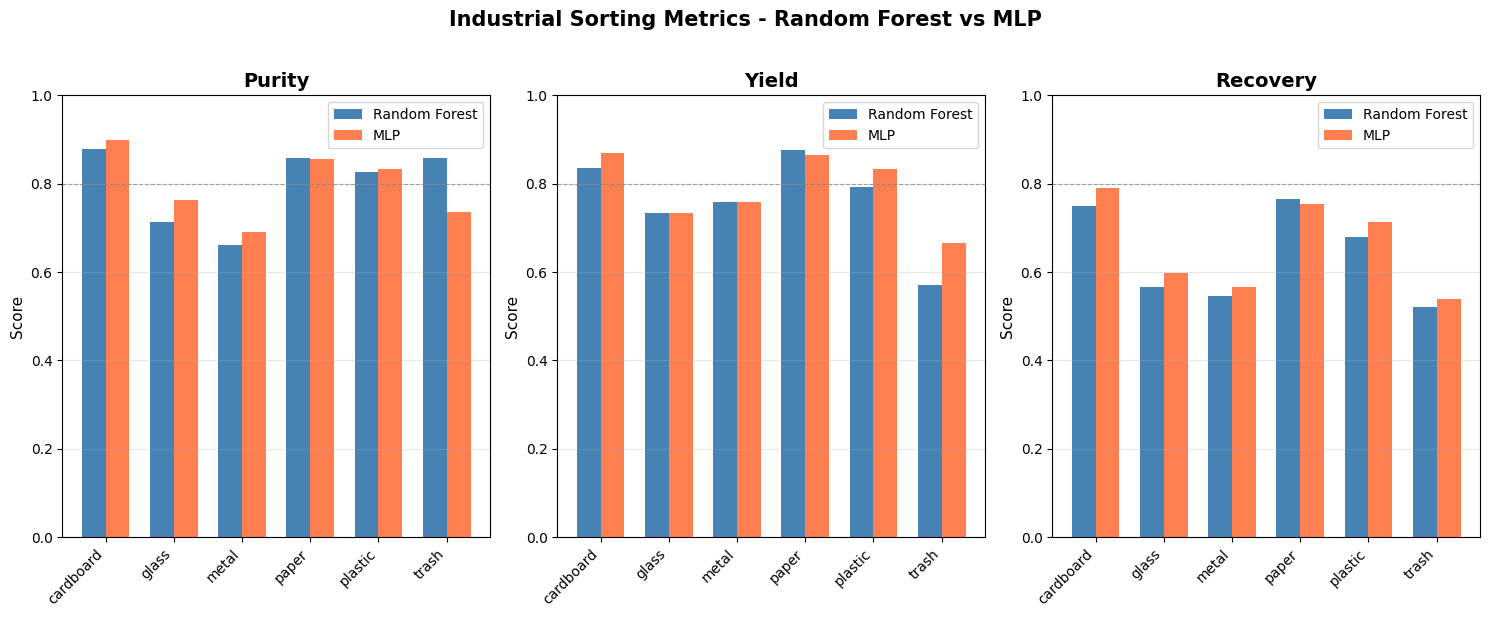

Saved: industrial_metrics.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

metrics    = ['Purity', 'Yield', 'Recovery']
titles     = ['Purity', 'Yield', 'Recovery']
x          = np.arange(len(CLASS_ORDER))
width      = 0.35

for ax, metric, title in zip(axes, metrics, titles):
    bars_rf  = ax.bar(x - width/2, rf_metrics[metric],  width, label='Random Forest', color='steelblue')
    bars_mlp = ax.bar(x + width/2, mlp_metrics[metric], width, label='MLP',           color='coral')
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_ORDER, rotation=45, ha='right', fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Score', fontsize=11)
    ax.legend(fontsize=10)
    ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Industrial Sorting Metrics - Random Forest vs MLP', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'industrial_metrics.png'), 
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: industrial_metrics.png")